In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

In [2]:
def load_results(path):
    df = pd.read_csv(path)

    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    for col in df.columns:
        if col.endswith("_all"):
            df[col] = (
                df[col]
                .str.replace('[', '')
                .str.replace(']', '')
                .apply(lambda x: [float(v) for v in x.split()])
            )
    return df

def to_long_feat(df, feat_label, metric="F1_macro"):
    rows = []

    for _, row in df.iterrows():
        model = row["Model"]
        scores = row[f"CV_{metric}_all"]

        for s in scores:
            rows.append({
                "FeatureEngineering": feat_label,
                "Model": model,
                metric: s
            })

    return pd.DataFrame(rows)

## TweetEmotionsPTBR

### Feat BoW

In [3]:
paths = {
    "WITHOUT_FEATURE_ENGINEERING": "../../data/out/baseline/baseline_03_TweetEmotionsPTBR_BoW.csv",
    "WITH_FEATURE_ENGINEERING": "../../data/out/feat/feat_03_TweetEmotionsPTBR_BoW.csv"
}

dfs = []

for name, path in paths.items():
    df = load_results(path)
    dfs.append(to_long_feat(df, name))

df_long = pd.concat(dfs, ignore_index=True)

df_pair = (
    df_long
    .groupby("FeatureEngineering")
    .head(df_long.groupby("FeatureEngineering").size().min())
    .reset_index(drop=True)
)

scores_without = (
    df_pair[df_pair["FeatureEngineering"] == "WITHOUT_FEATURE_ENGINEERING"]["F1_macro"]
    .to_numpy()
)

scores_with = (
    df_pair[df_pair["FeatureEngineering"] == "WITH_FEATURE_ENGINEERING"]["F1_macro"]
    .to_numpy()
)

stat, p = wilcoxon(scores_without, scores_with)

n = len(scores_without)
mean_w = n * (n + 1) / 4
std_w = np.sqrt(n * (n + 1) * (2*n + 1) / 24)

z = (stat - mean_w) / std_w
r = abs(z) / np.sqrt(n)

print(f"Wilcoxon stat = {stat:.4f}")
print(f"p-value = {p:.6f}")
print(f"Z = {z:.4f}")
print(f"Effect size (r) = {r:.4f}")

Wilcoxon stat = 3267.0000
p-value = 0.000011
Z = -4.4945
Effect size (r) = 0.3670


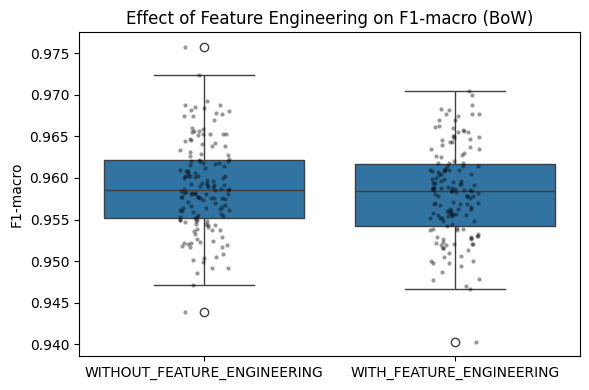

In [6]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_long,
    x="FeatureEngineering",
    y="F1_macro"
)

sns.stripplot(
    data=df_long,
    x="FeatureEngineering",
    y="F1_macro",
    color="black",
    alpha=0.4,
    size=3
)

plt.title("Effect of Feature Engineering on F1-macro (BoW)")
plt.xlabel("")
plt.ylabel("F1-macro")
plt.tight_layout()
plt.show()

### Feat TFIDF

In [7]:
paths = {
    "WITHOUT_FEATURE_ENGINEERING": "../../data/out/baseline/baseline_03_TweetEmotionsPTBR_TFIDF.csv",
    "WITH_FEATURE_ENGINEERING": "../../data/out/feat/feat_03_TweetEmotionsPTBR_TFIDF.csv"
}

dfs = []

for name, path in paths.items():
    df = load_results(path)
    dfs.append(to_long_feat(df, name))

df_long = pd.concat(dfs, ignore_index=True)

df_pair = (
    df_long
    .groupby("FeatureEngineering")
    .head(df_long.groupby("FeatureEngineering").size().min())
    .reset_index(drop=True)
)

scores_without = (
    df_pair[df_pair["FeatureEngineering"] == "WITHOUT_FEATURE_ENGINEERING"]["F1_macro"]
    .to_numpy()
)

scores_with = (
    df_pair[df_pair["FeatureEngineering"] == "WITH_FEATURE_ENGINEERING"]["F1_macro"]
    .to_numpy()
)

stat, p = wilcoxon(scores_without, scores_with)

n = len(scores_without)
mean_w = n * (n + 1) / 4
std_w = np.sqrt(n * (n + 1) * (2*n + 1) / 24)

z = (stat - mean_w) / std_w
r = abs(z) / np.sqrt(n)

print(f"Wilcoxon stat = {stat:.4f}")
print(f"p-value = {p:.6f}")
print(f"Z = {z:.4f}")
print(f"Effect size (r) = {r:.4f}")

Wilcoxon stat = 3250.0000
p-value = 0.000006
Z = -4.5264
Effect size (r) = 0.3696


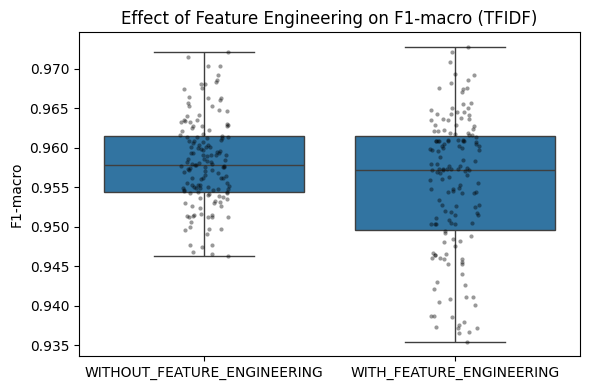

In [8]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_long,
    x="FeatureEngineering",
    y="F1_macro"
)

sns.stripplot(
    data=df_long,
    x="FeatureEngineering",
    y="F1_macro",
    color="black",
    alpha=0.4,
    size=3
)

plt.title("Effect of Feature Engineering on F1-macro (TFIDF)")
plt.xlabel("")
plt.ylabel("F1-macro")
plt.tight_layout()
plt.show()